# **Single-Cell Spatial Transcriptomics**
---
## *The Computer Science Side*
---

### Why use computers?
- How does biology becomes data?
- How do computers analyze cells?
- How does a computer help biology?
- What is Data Science?

---

#**Where do Computers come in?**

## Studying biological characteristics:

Studying:
- 1 cell → easy
- 10 cells → manageable
- 1,000,000 cells → impossible manually

---

Modern biology depends on the interplay of millions of cells and their functions. How do you understand similarities and differences across thousands of objects?

Scientists need:
- computers
- visualization
- algorithms

Without computing, modern biology would be impossible at this scale.

In [ ]:
print("Hello World!")

Hello World!


In [ ]:
print(1+1)

2


In [ ]:
variable = 3
print(variable)

3


In [ ]:
import math

# Basic math operations
print("Square root of 25:", math.sqrt(25))
print("Power 2^5:", math.pow(2, 5))
print("Value of pi:", math.pi)
print("Cos(0):", math.cos(0))
print("Factorial of 5:", math.factorial(5))

# Trigonometry
angle = math.radians(90)
print("Sin(90°):", math.sin(angle))

# Logarithms
print("Log base e of 10:", math.log(10))
print("Log base 10 of 1000:", math.log10(1000))

Square root of 25: 5.0
Power 2^5: 32.0
Value of pi: 3.141592653589793
Cos(0): 1.0
Factorial of 5: 120
Sin(90°): 1.0
Log base e of 10: 2.302585092994046
Log base 10 of 1000: 3.0


#**Try It Yourself**

In [ ]:
import math

In [ ]:
# Write Code Here

# What are Lists?

# What is a Loop?

# ...

In [ ]:
arr = [1,2,3,4,5]
for a in arr:
  print(a)


1
2
3
4
5


# What Does the Cell Look Like? (To a computer)

## A simplified gene table

| Cell | Gene A | Gene B | Gene C |
|------|------|------|------|
| Cell 1 | 10 | 2 | 0 |
| Cell 2 | 11 | 1 | 0 |
| Cell 3 | 0 | 9 | 8 |
| Cell 4 | 1 | 10 | 7 |

This is called a:

''' Gene Expression Matrix '''

--> Rows = cells  
--> Columns = genes  
--> Numbers = activity levels

# Start with an Analogy

## Biology works on similarity and differences

**Spotify groups:**
- similar songs <--> similar listeners

Similar cell groups -->
- similar cells
- similar gene activity
- similar behaviors

Same idea as Pattern recognition
---
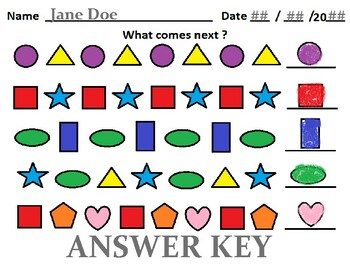


# What does the computer notice?

`Cells 1 and 2 look similar across expression of Gene 1.`

`Cells 3 and 4 look similar across exppression of Gene 3 and very different in Gene 2.`

So the computer groups them.

This is called:

''' Clustering '''

The computer is finding patterns automatically.

# What Makes It “Spatial”?

Normal Cell data:
- loses location information

Spatial transcriptomics stores:
- what the cell is doing (What genes it has)
- AND where the cell is located

Spatial Data:

| Cell | X | Y |
|------|------|------|
| Cell 1 | 2 | 5 |
| Cell 2 | 3 | 5 |
| Cell 3 | 9 | 1 |


Now computers can build tissue maps.

Complete Cell-Data-Matrix:
| Cell | Gene A | Gene B | Gene C | X | Y |
|------|------|------|------|------|------|
| Cell 1 | 10 | 2 | 0 | 0 | 2 |
| Cell 2 | 11 | 1 | 0 | 4 | 1 |
| Cell 3 | 0 | 9 | 8 | 2 | 1 |
| Cell 4 | 1 | 10 | 7 | 3 | 1 |

In [39]:
#@title
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

def draw_spatial_maps(
    df,
    x_col='X',
    y_col='Y',
    cell_col='Cell',
    cmap='viridis',
    point_size=300,
    figsize_per_plot=(5, 4)
):
    """
    Draw spatial expression maps for all gene columns in a dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing:
        - cell labels
        - X/Y coordinates
        - gene expression columns

    x_col : str
        Column name for X coordinates

    y_col : str
        Column name for Y coordinates

    cell_col : str
        Column name for cell labels

    cmap : str
        Matplotlib colormap

    point_size : int
        Size of scatter points

    figsize_per_plot : tuple
        Size of each subplot
    """

    gene_cols = [
        col for col in df.columns
        if col not in [cell_col, x_col, y_col]
    ]

    n_genes = len(gene_cols)

    fig, axes = plt.subplots(
        1,
        n_genes,
        figsize=(figsize_per_plot[0] * n_genes,
                 figsize_per_plot[1])
    )

    if n_genes == 1:
        axes = [axes]

    for ax, gene in zip(axes, gene_cols):

        scatter = ax.scatter(
            df[x_col],
            df[y_col],
            c=df[gene],
            s=point_size,
            cmap=cmap,
            edgecolor='black'
        )

        if len(df) <= 20:
          annotate = True
        else:
          annotate = False
        if(annotate):
          for _, row in df.iterrows():
              ax.annotate(
                  row[cell_col],
                  (row[x_col], row[y_col]),
                  textcoords="offset points",
                  xytext=(0, 10),
                  ha='center'
              )

        ax.set_title(f'{gene} Expression')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

        ax.grid(True, linestyle='--', alpha=0.5)

        plt.colorbar(scatter, ax=ax)

    plt.tight_layout()
    plt.show()

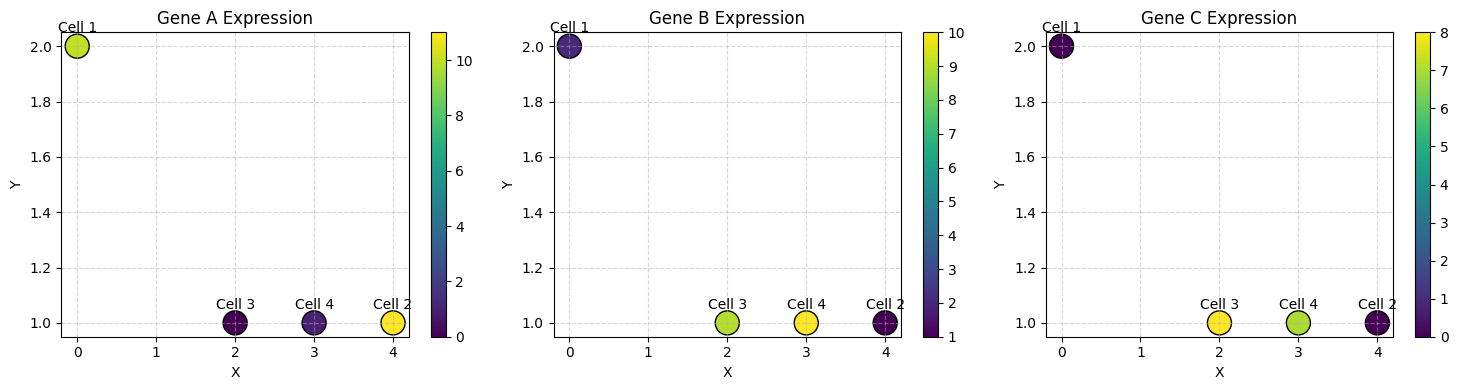

In [41]:
data = {
    'Cell': ['Cell 1', 'Cell 2', 'Cell 3', 'Cell 4'],
    'Gene A': [10, 11, 0, 1],
    'Gene B': [2, 1, 9, 10],
    'Gene C': [0, 0, 8, 7],
    'X': [0, 4, 2, 3],
    'Y': [2, 1, 1, 1]
}

df = pd.DataFrame(data)
draw_spatial_maps(df)

In [51]:
# @title
more_data = {
    'Cell': [
        'Cell 1', 'Cell 2', 'Cell 3', 'Cell 4', 'Cell 5',
        'Cell 6', 'Cell 7', 'Cell 8', 'Cell 9', 'Cell 10',
        'Cell 11', 'Cell 12', 'Cell 13', 'Cell 14', 'Cell 15',
        'Cell 16', 'Cell 17', 'Cell 18', 'Cell 19', 'Cell 20',
        'Cell 21', 'Cell 22', 'Cell 23', 'Cell 24', 'Cell 25',
        'Cell 26', 'Cell 27', 'Cell 28', 'Cell 29', 'Cell 30'
    ],

    # Cluster 1 → Gene A dominant
    'Gene A': [
        14, 13, 15, 12, 14,
        13, 12, 11, 10, 12,

        # Cluster 2 → Gene B dominant
        2, 1, 2, 3, 1,
        2, 1, 2, 3, 2,

        # Cluster 3 → Gene C dominant
        0, 1, 0, 1, 2,
        1, 0, 1, 2, 1
    ],

    'Gene B': [
        1, 2, 1, 2, 1,
        2, 1, 2, 3, 2,

        14, 15, 13, 14, 15,
        12, 13, 14, 15, 13,

        2, 1, 2, 1, 2,
        1, 2, 1, 2, 1
    ],

    'Gene C': [
        0, 1, 0, 1, 0,
        1, 0, 1, 2, 1,

        2, 1, 2, 1, 2,
        1, 2, 1, 2, 1,

        13, 14, 15, 14, 13,
        15, 14, 13, 12, 14
    ],

    # Sparse clustered coordinates
    'X': [
        # Cluster 1 (top-left)
        0, 1, 1, 2, 2,
        3, 3, 4, 4, 5,

        # Cluster 2 (middle-right)
        6, 7, 7, 8, 8,
        9, 9, 7, 8, 9,

        # Cluster 3 (bottom-middle)
        2, 3, 3, 4, 4,
        5, 5, 6, 6, 7
    ],

    'Y': [
        # Cluster 1
        3, 3, 2, 3, 2,
        3, 2, 3, 2, 2,

        # Cluster 2
        2, 3, 2, 3, 2,
        3, 2, 1, 1, 1,

        # Cluster 3
        0, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ]
}

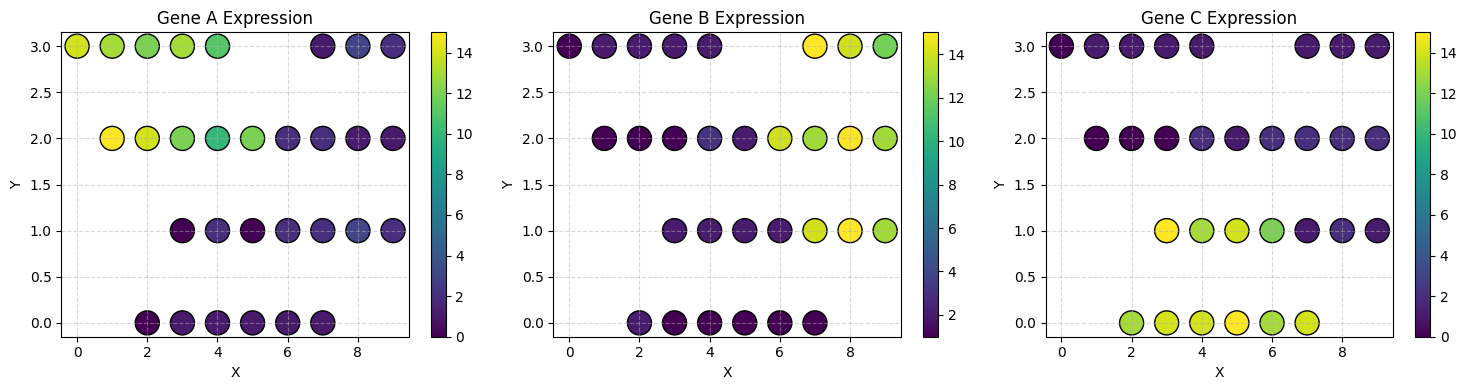

In [52]:
import pandas as pd

df = pd.DataFrame(more_data)
draw_spatial_maps(df)

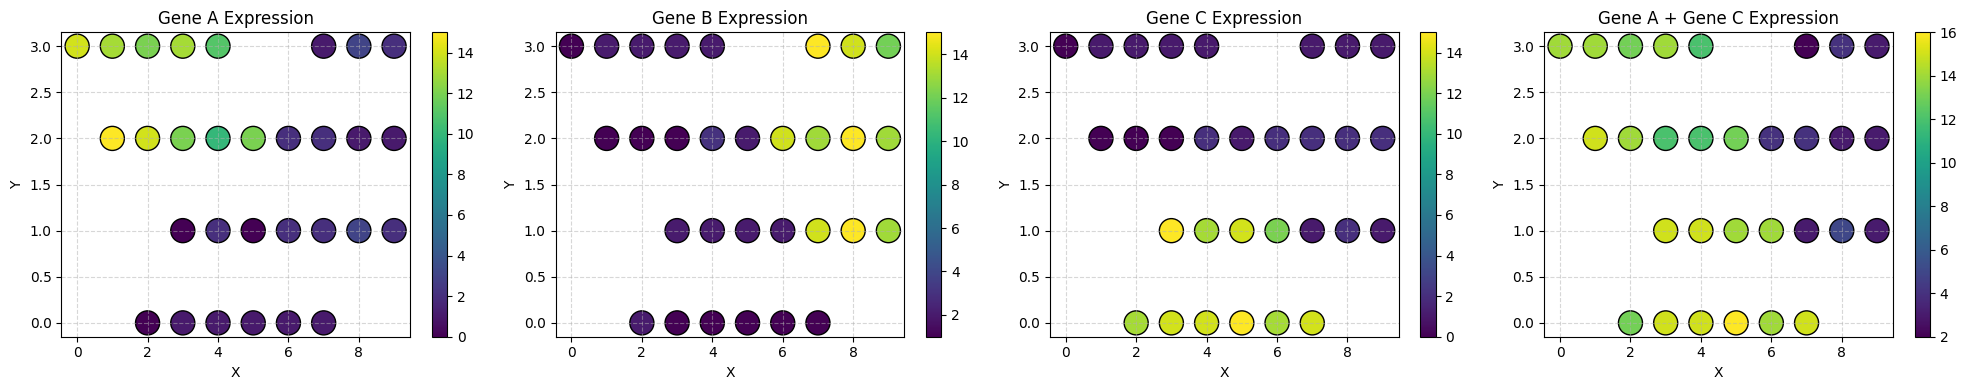

In [53]:
import pandas as pd

more_data['Gene A + Gene C'] = [
    a + c for a, c in zip(more_data['Gene A'], more_data['Gene C'])
]

df = pd.DataFrame(more_data)
draw_spatial_maps(df)

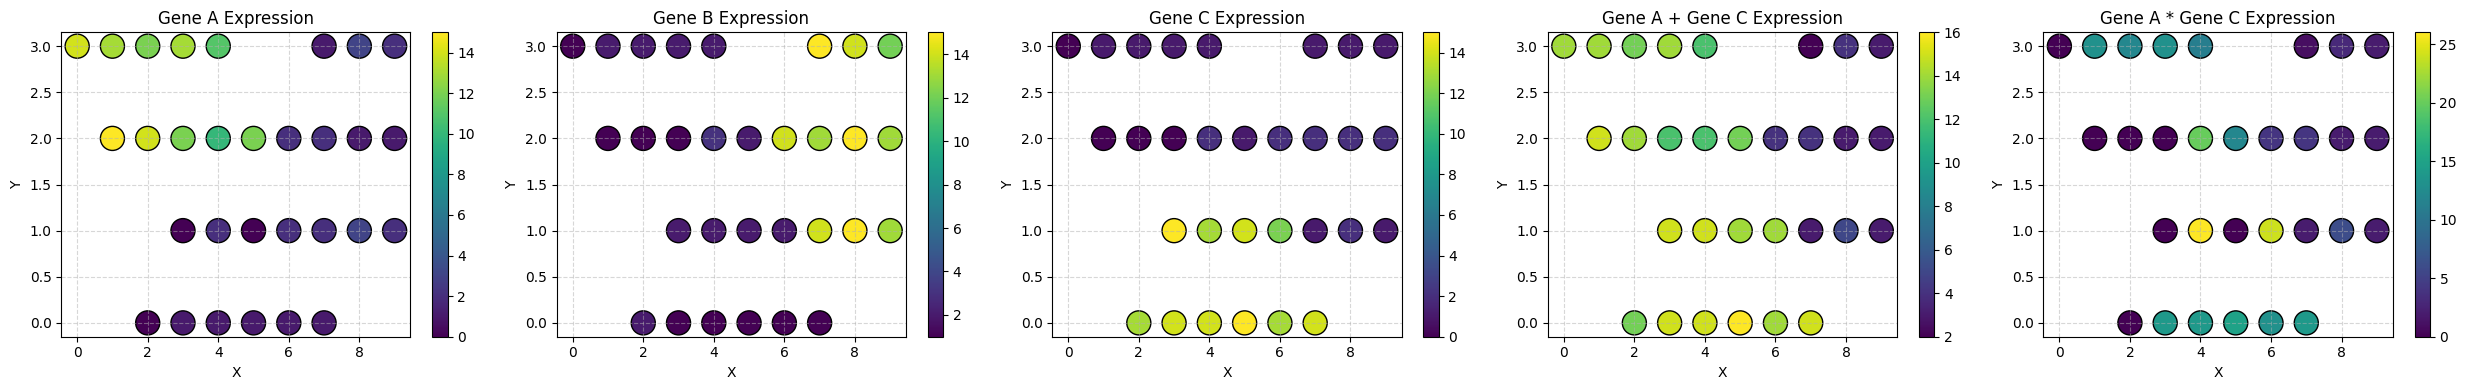

In [54]:
import pandas as pd

more_data['Gene A * Gene C'] = [
    a * c for a, c in zip(more_data['Gene A'], more_data['Gene C'])
]

df = pd.DataFrame(more_data)
draw_spatial_maps(df)

# Why Does This Matter?

This technology helps scientists:
- study cancer
- understand the brain*
- design medicines
- study immune systems

Modern Biology is aided by:
> Data science Concepts

# Skills you'll learn —

This field combines:

| Field | Role |
|------|------|
| Biology | Understanding cells |
| Computer Science | Algorithms |
| AI | Pattern detection |
| Data Science | Analysis |
| Visualization | Scientific graphics |